## TP-1 - Introduction to Information Retrieval

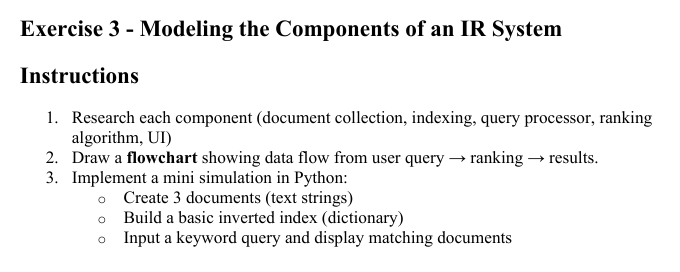

## 1. Research on IR System Components

Document Collection: The raw data source containing all documents to be searched
Indexing: Process of creating data structures (inverted index) for fast retrieval
Query Processor: Handles user queries, tokenization, and query expansion
Ranking Algorithm: Scores and sorts documents by relevance (TF-IDF, BM25, etc.)
UI: User interface for inputting queries and displaying results

## 2. Flowchart

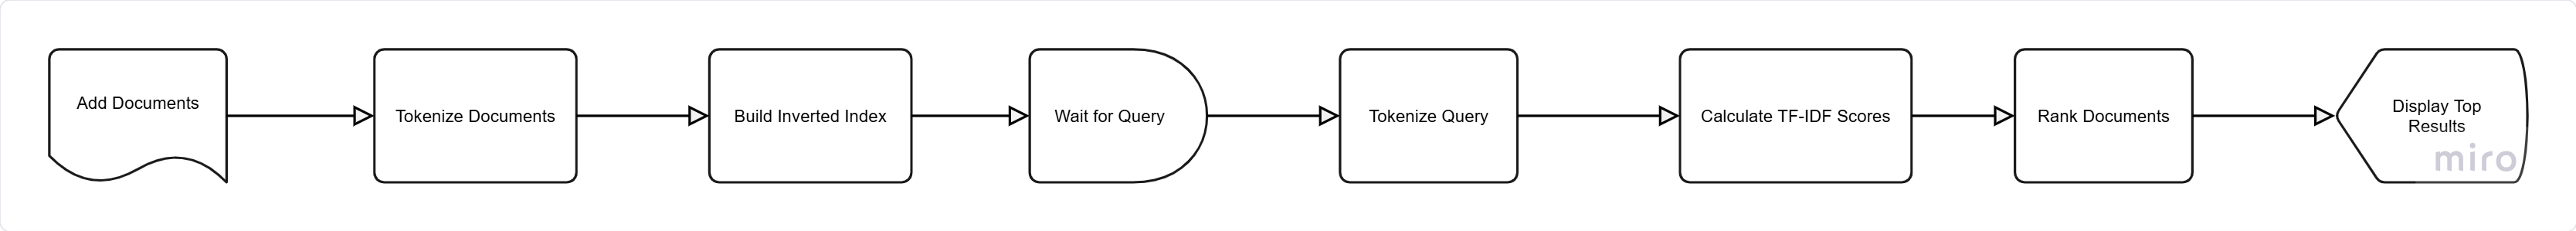

## 3. Python Implementation

In [ ]:
import math
import re
from collections import defaultdict

class SimpleIRSystem:
    def __init__(self):
        self.documents = []
        self.inverted_index = defaultdict(set)
        self.doc_frequency = defaultdict(int)
        self.term_frequency = defaultdict(lambda: defaultdict(int))
        
    def add_document(self, doc_text, doc_id=None):
        """Add a document to the collection"""
        if doc_id is None:
            doc_id = len(self.documents)
        self.documents.append(doc_text)
        self._index_document(doc_text, doc_id)
        return doc_id
    
    def _tokenize(self, text):
        """Basic tokenization - convert to lowercase and split on non-alphanumeric"""
        text = text.lower()
        tokens = re.findall(r'\b\w+\b', text)
        return tokens
    
    def _index_document(self, doc_text, doc_id):
        """Build inverted index for a document"""
        tokens = self._tokenize(doc_text)
        
        for token in tokens:
            self.inverted_index[token].add(doc_id)
            self.term_frequency[doc_id][token] += 1
        
        # Update document frequency for each unique term in document
        for token in set(tokens):
            self.doc_frequency[token] += 1
    
    def tf_idf_score(self, term, doc_id):
        """Calculate TF-IDF score for a term in a document"""
        if doc_id not in self.term_frequency or term not in self.term_frequency[doc_id]:
            return 0
        
        # Term Frequency (raw count)
        tf = self.term_frequency[doc_id][term]
        
        # Inverse Document Frequency
        N = len(self.documents)
        df = self.doc_frequency[term]
        idf = math.log((N + 1) / (df + 1)) + 1  # Smoothing
        
        return tf * idf
    
    def search(self, query, top_k=3):
        """Search documents using TF-IDF ranking"""
        query_terms = self._tokenize(query)
        
        if not query_terms:
            return []
        
        # Get candidate documents (OR operation)
        candidate_docs = set()
        for term in query_terms:
            if term in self.inverted_index:
                candidate_docs.update(self.inverted_index[term])
        
        # Score documents using TF-IDF
        doc_scores = []
        for doc_id in candidate_docs:
            score = 0
            for term in query_terms:
                score += self.tf_idf_score(term, doc_id)
            doc_scores.append((doc_id, score))
        
        # Sort by score descending
        doc_scores.sort(key=lambda x: x[1], reverse=True)
        
        return doc_scores[:top_k]
    
    def display_results(self, query, results):
        """Display search results in a user-friendly format"""
        print(f"\n{'='*50}")
        print(f"QUERY: '{query}'")
        print(f"RESULTS FOUND: {len(results)}")
        print(f"{'='*50}")
        
        for rank, (doc_id, score) in enumerate(results, 1):
            doc_preview = self.documents[doc_id][:100] + "..." if len(self.documents[doc_id]) > 100 else self.documents[doc_id]
            print(f"\nRank {rank} (Score: {score:.4f}):")
            print(f"Document {doc_id}: {doc_preview}")
    
    def display_index_stats(self):
        """Display indexing statistics"""
        print(f"\n{'='*30}")
        print("INDEX STATISTICS")
        print(f"{'='*30}")
        print(f"Total Documents: {len(self.documents)}")
        print(f"Unique Terms: {len(self.inverted_index)}")
        print(f"\nSample Index Entries:")
        for i, (term, docs) in enumerate(list(self.inverted_index.items())[:5]):
            print(f"  '{term}': {list(docs)}")

def main():
    # Create IR System instance
    ir_system = SimpleIRSystem()
    
    # Create 3 sample documents
    documents = [
        "The quick brown fox jumps over the lazy dog. Dogs and foxes are animals.",
        "Machine learning is a subset of artificial intelligence. AI is transforming the world.",
        "Python programming language is used for data science and web development. Python is versatile."
    ]
    
    # Add documents to the system
    print("Adding documents to IR system...")
    for i, doc in enumerate(documents):
        ir_system.add_document(doc, i)
        print(f"Document {i}: {doc[:50]}...")
    
    # Display index statistics
    ir_system.display_index_stats()
    
    # Interactive search loop
    print(f"\n{'='*50}")
    print("INTERACTIVE SEARCH")
    print(f"{'='*50}")
    print("Type 'quit' to exit")
    
    while True:
        query = input("\nEnter your search query: ").strip()
        
        if query.lower() == 'quit':
            break
            
        if not query:
            print("Please enter a query.")
            continue
        
        # Perform search and display results
        results = ir_system.search(query)
        ir_system.display_results(query, results)

if __name__ == "__main__":
    main()

Adding documents to IR system...
Document 0: The quick brown fox jumps over the lazy dog. Dogs ...
Document 1: Machine learning is a subset of artificial intelli...
Document 2: Python programming language is used for data scien...

INDEX STATISTICS
Total Documents: 3
Unique Terms: 34

Sample Index Entries:
  'the': [0, 1]
  'quick': [0]
  'brown': [0]
  'fox': [0]
  'jumps': [0]

INTERACTIVE SEARCH
Type 'quit' to exit
Please enter a query.

QUERY: 'python'
RESULTS FOUND: 1

Rank 1 (Score: 3.3863):
Document 2: Python programming language is used for data science and web development. Python is versatile.

QUERY: 'python'
RESULTS FOUND: 1

Rank 1 (Score: 3.3863):
Document 2: Python programming language is used for data science and web development. Python is versatile.

QUERY: 'machine learning'
RESULTS FOUND: 1

Rank 1 (Score: 3.3863):
Document 1: Machine learning is a subset of artificial intelligence. AI is transforming the world.

QUERY: 'machine learning'
RESULTS FOUND: 1

Rank 1 (Sco

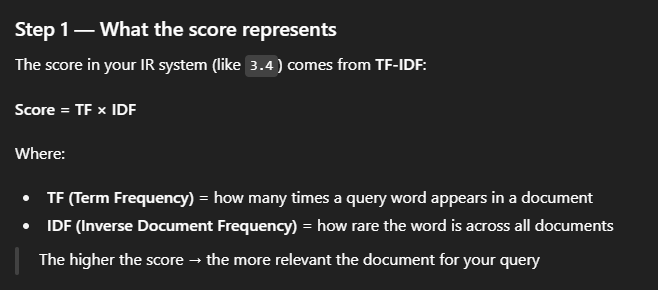

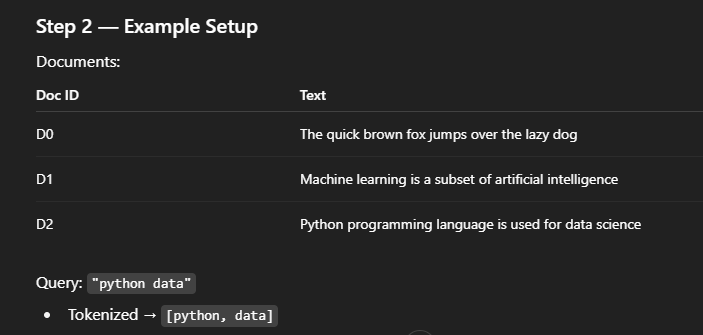

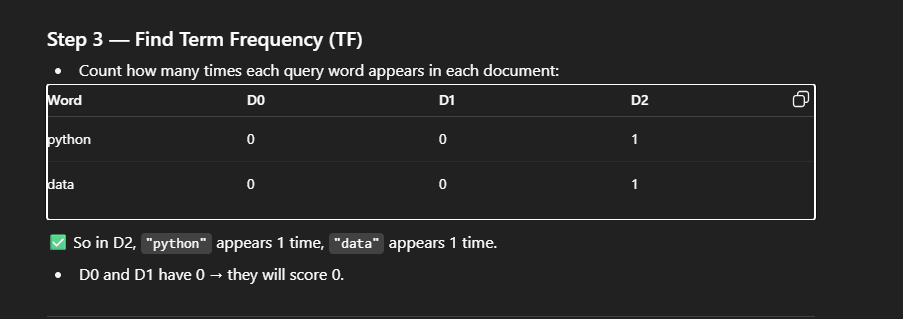

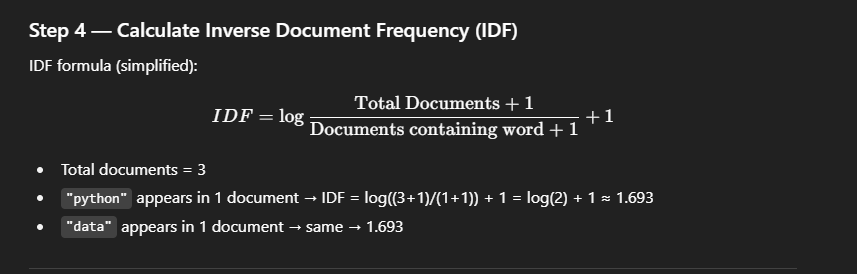

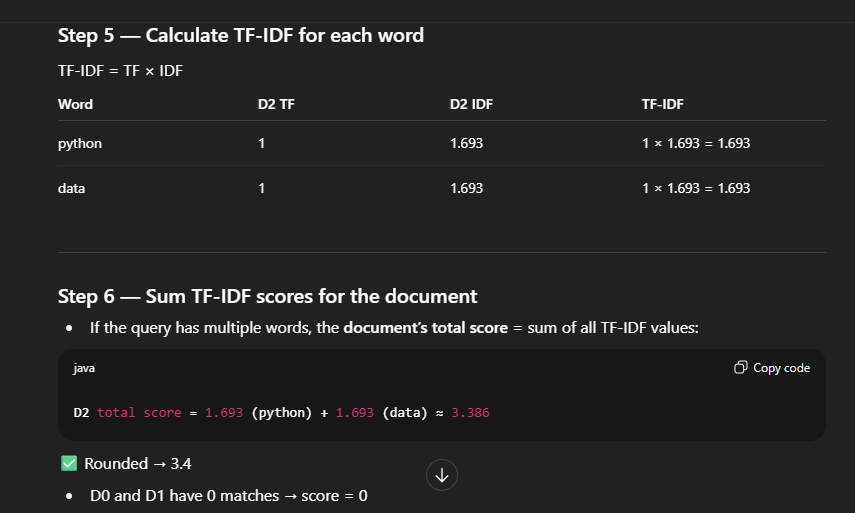

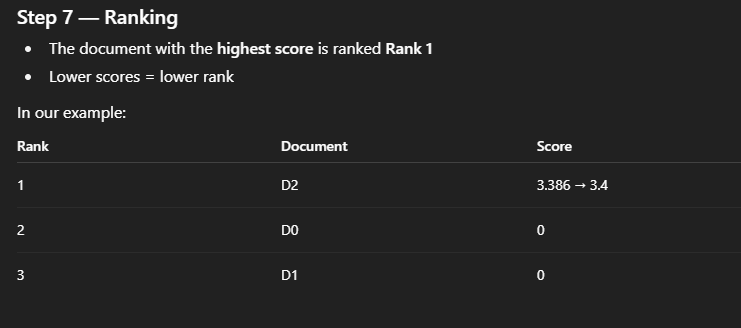